In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patheffects as path_effects
from matplotlib.colors import LinearSegmentedColormap

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'savefig.facecolor': 'white',
    'figure.edgecolor': 'white',

    # Text colors to black
    'text.color': 'black',
    'axes.labelcolor': 'black',
    'axes.titlecolor': 'black',
    'ytick.color': 'black',
    'xtick.color': 'black',
    'legend.labelcolor': 'black',

    # Tick labels
    'xtick.labelcolor': 'black',
    'ytick.labelcolor': 'black',
    # Axis spines, ticks, and edges to black
    'axes.edgecolor': 'black',
    'xtick.color': 'black',
    'ytick.color': 'black',
    'axes.linewidth': 0.8,
})


In [4]:
def create_ice_cmap():
    return LinearSegmentedColormap.from_list("ice_blue",
           ["#000814", "#001D3D", "#003566", "#3E92CC", "#D1E9FF"])

def clean_param(val):
    if isinstance(val, str):
        for char in ['±', '+', '-', ' ']: val = val.split(char)[0]
    try: return float(val)
    except: return 0.0

def solve_Ufree(Ut, S, Kb=0.5):
    Ut = np.asarray(Ut, dtype=float)
    D = (S + Kb - Ut)**2 + 4.0 * Ut * Kb
    return 0.5 * (Ut - S - Kb + np.sqrt(D))

def phi_log(Uf, S, Kb=0.5):
    return (1.0 + S / (Kb + Uf)) / (1.0 + (S * Kb) / (Kb + Uf)**2)

def get_gain(C_TetR, C_Z, omega_TetR_unit,stability_factor, Kd_Y_SR, n_Y, beta_Y, X_vals):
    """
    C_Y = 15 is constant for all.
    omega_TetR_unit is the max production capacity PER COPY of the C_TetR plasmid.
    """
    rho_TetR = omega_TetR_unit * C_TetR*stability_factor
    rho_Z = 100.0 * C_Z #approximation
    S_TetR_target = C_Z * 2.0

    S_X = 1.0 * C_TetR
    X_free = solve_Ufree(X_vals, S_X, 1.0)
    s_X = X_free / Kd_Y_SR

    TetR_tot = rho_TetR * (beta_Y + (1.0 - beta_Y) * (s_X**n_Y) / (1.0 + s_X**n_Y))
    dTetR_dlogX = rho_TetR * (1.0 - beta_Y) * n_Y * (s_X**n_Y) / (1.0 + s_X**n_Y)**2

    TetR_free = solve_Ufree(TetR_tot, S_TetR_target, 0.5)
    s_TetR = TetR_free / 1.0

    dZ_dlogTetR = rho_Z * (1.0 - 0.015) * 2.0 * (s_TetR**2.0) / (1.0 + s_TetR**2.0)**2

    Phi_Y = phi_log(TetR_free, S_TetR_target, 0.5)
    Phi_X = phi_log(X_free, S_X, 1.0)

    sens = dZ_dlogTetR * Phi_Y * (1.0 / TetR_tot) * dTetR_dlogX * Phi_X
    return np.max(sens)

def get_gain_penalty(C_TetR, C_Z, omega_TetR_unit, stability_factor, Kd_Y_SR, n_Y, beta_Y, X_vals):
    protein_load = C_TetR * stability_factor
    scaffold_capacity = C_Z * 2.0

    toxicity_ratio = protein_load / scaffold_capacity
    aggregation_penalty = 1.0 / (1.0 + (toxicity_ratio / 2.0)**2)

    rho_TetR = omega_TetR_unit * protein_load * aggregation_penalty
    rho_Z = 100.0 * C_Z
    S_TetR_target = C_Z * 2.0

    S_X = 1.0 * C_TetR
    X_free = solve_Ufree(X_vals, S_X, 1.0)
    s_X = X_free / Kd_Y_SR

    TetR_tot = rho_TetR * (beta_Y + (1.0 - beta_Y) * (s_X**n_Y) / (1.0 + s_X**n_Y))
    dTetR_dlogX = rho_TetR * (1.0 - beta_Y) * n_Y * (s_X**n_Y) / (1.0 + s_X**n_Y)**2

    TetR_free = solve_Ufree(TetR_tot, S_TetR_target, 0.5)
    s_TetR = TetR_free / 1.0

    dZ_dlogTetR = rho_Z * (1.0 - 0.015) * 2.0 * (s_TetR**2.0) / (1.0 + s_TetR**2.0)**2

    Phi_Y = phi_log(TetR_free, S_TetR_target, 0.5)
    Phi_X = phi_log(X_free, S_X, 1.0)

    sens = dZ_dlogTetR * Phi_Y * (1.0 / TetR_tot) * dTetR_dlogX * Phi_X
    return np.max(sens)

In [5]:
filename = 'Heme_final_stats.csv'
df = pd.read_csv(filename)
df['Kd'] = df['Kd'].apply(clean_param)
df['Beta'] = df['Beta'].apply(clean_param)
emp = {row['Construct']: row for _, row in df.iterrows()}

prefix = 'H' if 'Heme' in filename else 'L'

Kd_Y_SR = emp[f'{prefix}D1']['Kd']
n_Y = clean_param(emp[f'{prefix}D1']['Hill (n)'])
beta_Y = emp[f'{prefix}D1']['Beta']

# anchoring C_Y=15, C_TetR=40, C_Z=40
Kd_eff_D2 = emp[f'{prefix}D2']['Kd']
f_req = (Kd_eff_D2**n_Y) / (Kd_Y_SR**n_Y + Kd_eff_D2**n_Y)
S_TetR_D2 = 40.0 * 2.0
TetR_tot_target = 1.0 + S_TetR_D2 * (1.0 / (0.5 + 1.0))
rho_TetR_D2 = TetR_tot_target / (beta_Y + (1.0 - beta_Y) * f_req)
omega_TetR_unit = rho_TetR_D2 / 40.0
is_heme = 'Heme' in filename

if is_heme:
    designs = {
        'HD2': {'C_Z': 40, 'C_TetR': 40, 'color': '#AAAAAA'}, # best
        'HD3': {'C_Z': 6,  'C_TetR': 40, 'color': '#FFFFFF'}, # works
        'HD4': {'C_Z': 40, 'C_TetR': 6,  'color': '#00BFFF'}  # flatline
    }
else:
    designs = {
        'LD2': {'C_Z': 40, 'C_TetR': 40, 'color': '#AAAAAA'},
        'LD3': {'C_Z': 40, 'C_TetR': 6,  'color': '#FFFFFF'}, # works but weaker
        'LD4': {'C_Z': 6,  'C_TetR': 40, 'color': '#00BFFF'}  # flatline
    }

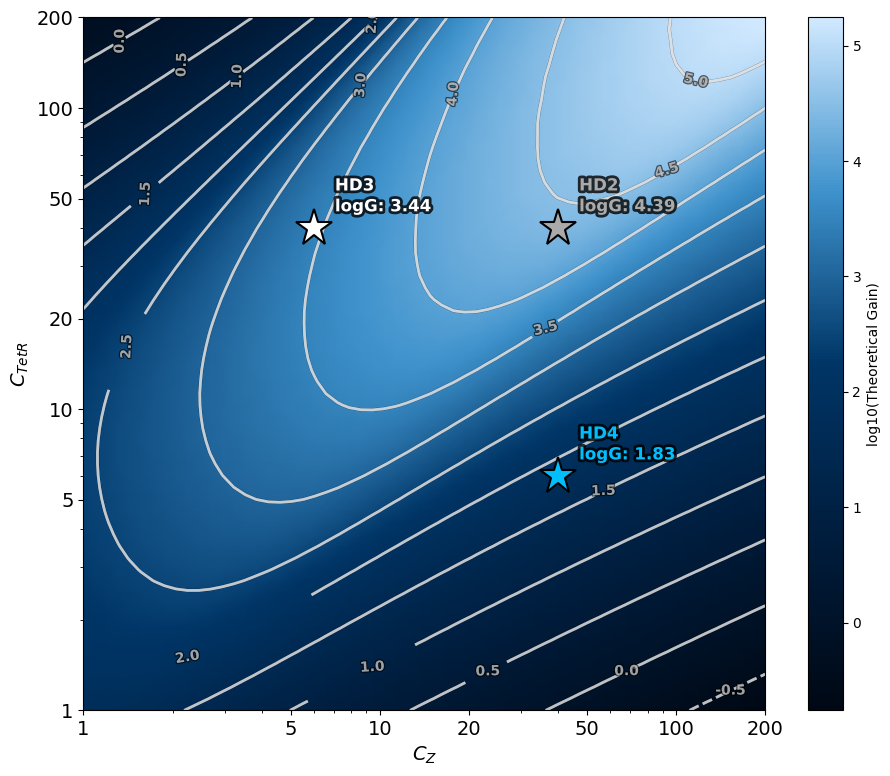

In [6]:
num = 60
C_range = np.logspace(0, 2.3, num)
X_vals = np.logspace(-2, 3, 1000)
CZ_m, CT_m = np.meshgrid(C_range, C_range)
gain_m = np.zeros((num, num))
stability_factor = 1
for i, ct in enumerate(C_range):
    for j, cz in enumerate(C_range):
        gain_m[i, j] = get_gain(ct, cz, omega_TetR_unit,1, Kd_Y_SR, n_Y, beta_Y, X_vals)

fig, ax = plt.subplots(figsize=(11, 9))
im = ax.pcolormesh(CZ_m, CT_m, np.log10(gain_m + 1e-5), cmap=create_ice_cmap(), shading='gouraud')

CS = ax.contour(CZ_m, CT_m, np.log10(gain_m + 1e-5), colors='white', linewidths=2.0, alpha=0.5, levels=12)
plt.setp(CS.collections, path_effects=[path_effects.withStroke(linewidth=2.5, foreground='#000000', alpha=0.4), path_effects.Normal()])
clbls = ax.clabel(CS, inline=True, fontsize=10, fmt='%1.1f', colors='white')
plt.setp(clbls, fontweight='bold', path_effects=[path_effects.withStroke(linewidth=1.8, foreground='#000000', alpha=0.6)])

for name, s in designs.items():
    g = get_gain(s['C_TetR'], s['C_Z'], omega_TetR_unit,1, Kd_Y_SR, n_Y, beta_Y, X_vals)
    ax.plot(s['C_Z'], s['C_TetR'], marker='*', markersize=28, color=s['color'],
            markeredgecolor='black', markeredgewidth=1.5, zorder=10)
    txt = ax.annotate(f"{name}\nlogG: {np.log10(g + 1e-5):.2f}",
                      xy=(s['C_Z'], s['C_TetR']), xytext=(15, 12), textcoords='offset points',
                      color=s['color'], fontsize=12, fontweight='bold', zorder=11)
    txt.set_path_effects([path_effects.withStroke(linewidth=4, foreground='black', alpha=0.8)])

ax.set_xscale('log'); ax.set_yscale('log')
ticks = [1, 5, 10, 20, 50, 100, 200]
ax.set_xticks(ticks)
ax.set_yticks(ticks)
ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())
ax.get_yaxis().set_major_formatter(plt.ScalarFormatter())
ax.set_xlabel('$C_Z$', fontsize=14)
ax.set_ylabel('$C_{TetR}$', fontsize=14)
plt.tick_params(axis='both', labelsize=14)
plt.colorbar(im, label='log10(Theoretical Gain)')
plt.show()

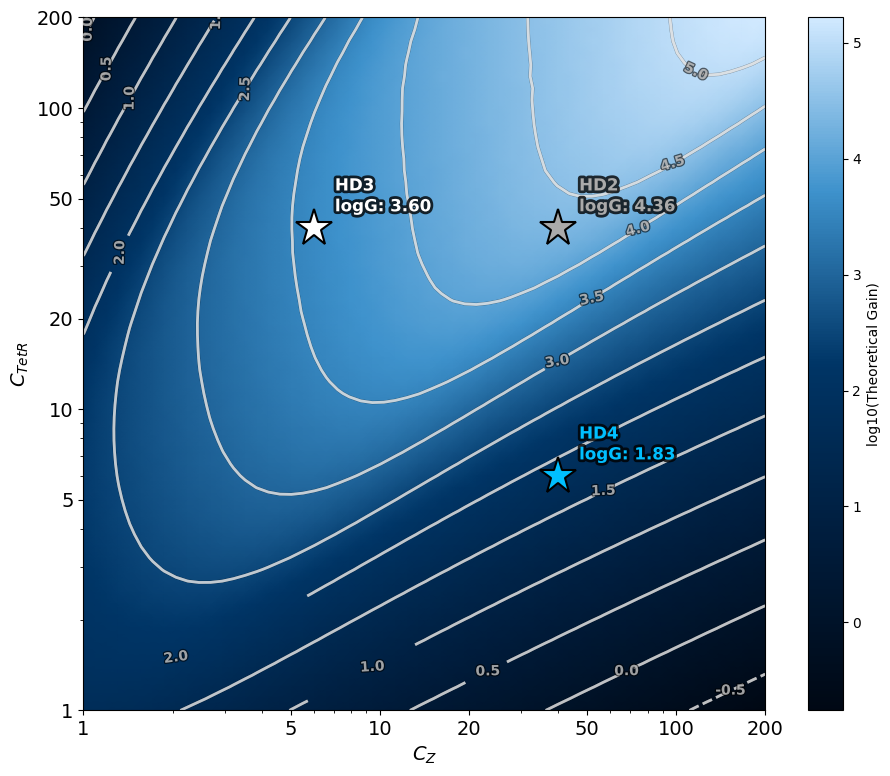

In [7]:
num = 60
C_range = np.logspace(0, 2.3, num)
X_vals = np.logspace(-2, 3, 1000)
CZ_m, CT_m = np.meshgrid(C_range, C_range)
gain_m = np.zeros((num, num))

for i, ct in enumerate(C_range):
    for j, cz in enumerate(C_range):
        gain_m[i, j] = get_gain_penalty(ct, cz, omega_TetR_unit,stability_factor, Kd_Y_SR, n_Y, beta_Y, X_vals)

fig, ax = plt.subplots(figsize=(11, 9))
im = ax.pcolormesh(CZ_m, CT_m, np.log10(gain_m + 1e-5), cmap=create_ice_cmap(), shading='gouraud')

CS = ax.contour(CZ_m, CT_m, np.log10(gain_m + 1e-5), colors='white', linewidths=2.0, alpha=0.5, levels=12)
plt.setp(CS.collections, path_effects=[path_effects.withStroke(linewidth=2.5, foreground='#000000', alpha=0.4), path_effects.Normal()])
clbls = ax.clabel(CS, inline=True, fontsize=10, fmt='%1.1f', colors='white')
plt.setp(clbls, fontweight='bold', path_effects=[path_effects.withStroke(linewidth=1.8, foreground='#000000', alpha=0.6)])

for name, s in designs.items():
    g = get_gain_penalty(s['C_TetR'], s['C_Z'], omega_TetR_unit,stability_factor, Kd_Y_SR, n_Y, beta_Y, X_vals)
    ax.plot(s['C_Z'], s['C_TetR'], marker='*', markersize=28, color=s['color'],
            markeredgecolor='black', markeredgewidth=1.5, zorder=10)
    txt = ax.annotate(f"{name}\nlogG: {np.log10(g + 1e-5):.2f}",
                      xy=(s['C_Z'], s['C_TetR']), xytext=(15, 12), textcoords='offset points',
                      color=s['color'], fontsize=12, fontweight='bold', zorder=11)
    txt.set_path_effects([path_effects.withStroke(linewidth=4, foreground='black', alpha=0.8)])

ax.set_xscale('log'); ax.set_yscale('log')
ticks = [1, 5, 10, 20, 50, 100, 200]
ax.set_xticks(ticks)
ax.set_yticks(ticks)
ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())
ax.get_yaxis().set_major_formatter(plt.ScalarFormatter())
ax.set_xlabel('$C_Z$', fontsize=14)
ax.set_ylabel('$C_{TetR}$', fontsize=14)
plt.tick_params(axis='both', labelsize=14)
plt.colorbar(im, label='log10(Theoretical Gain)')
plt.show()

In [8]:
filename = 'Lactate_final_stats.csv'
df = pd.read_csv(filename)
df['Kd'] = df['Kd'].apply(clean_param)
df['Beta'] = df['Beta'].apply(clean_param)
emp = {row['Construct']: row for _, row in df.iterrows()}

prefix = 'H' if 'Heme' in filename else 'L'

# SR  C_Y=15, C_Z_SR=40
Kd_Y_SR = emp[f'{prefix}D1']['Kd']
n_Y = clean_param(emp[f'{prefix}D1']['Hill (n)'])
beta_Y = emp[f'{prefix}D1']['Beta']

Kd_eff_D2 = emp[f'{prefix}D2']['Kd']
f_req = (Kd_eff_D2**n_Y) / (Kd_Y_SR**n_Y + Kd_eff_D2**n_Y)
S_TetR_D2 = 40.0 * 2.0
TetR_tot_target = 1.0 + S_TetR_D2 * (1.0 / (0.5 + 1.0))
rho_TetR_D2 = TetR_tot_target / (beta_Y + (1.0 - beta_Y) * f_req)
omega_TetR_unit = rho_TetR_D2 / 40.0

is_heme = 'Heme' in filename

if is_heme:
    designs = {
        'HD2': {'C_Z': 40, 'C_TetR': 40, 'color': '#AAAAAA'}, # best
        'HD3': {'C_Z': 6,  'C_TetR': 40, 'color': '#FFFFFF'}, # works
        'HD4': {'C_Z': 40, 'C_TetR': 6,  'color': '#00BFFF'}  # flatline
    }
else:
    designs = {
        'LD2': {'C_Z': 40, 'C_TetR': 40, 'color': '#AAAAAA'},
        'LD3': {'C_Z': 40, 'C_TetR': 6,  'color': '#FFFFFF'}, # works but weaker
        'LD4': {'C_Z': 6,  'C_TetR': 40, 'color': '#00BFFF'}  # flatline
    }

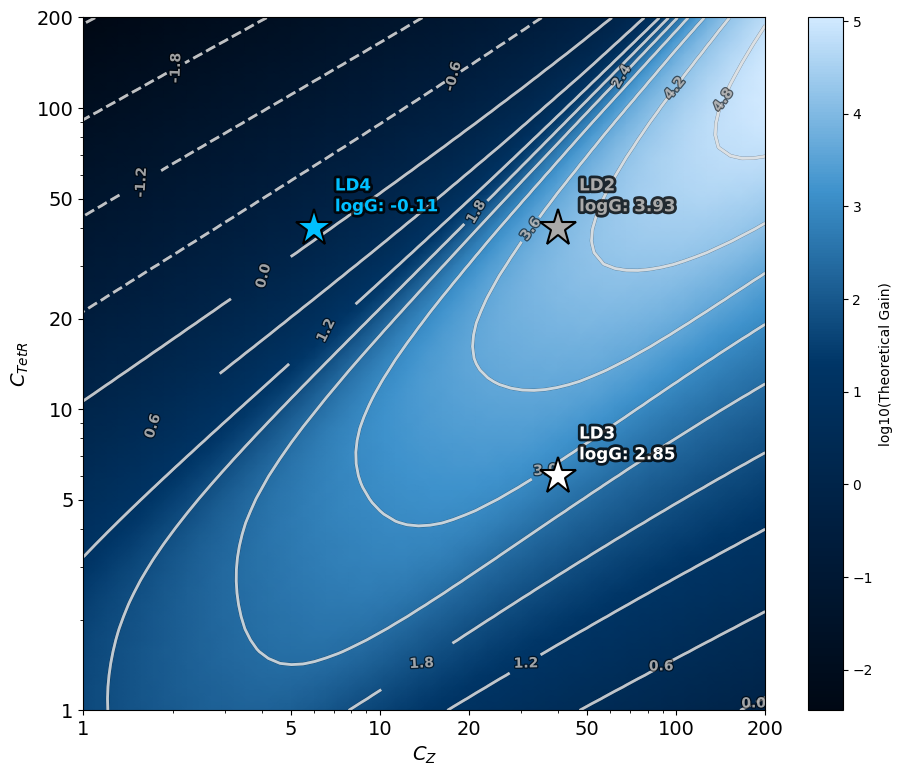

In [9]:
num = 60
C_range = np.logspace(0, 2.3, num)
X_vals = np.logspace(-2, 3, 1000)
CZ_m, CT_m = np.meshgrid(C_range, C_range)
gain_m = np.zeros((num, num))
stability_factor = 1
for i, ct in enumerate(C_range):
    for j, cz in enumerate(C_range):
        gain_m[i, j] = get_gain(ct, cz, omega_TetR_unit,1, Kd_Y_SR, n_Y, beta_Y, X_vals)

fig, ax = plt.subplots(figsize=(11, 9))
im = ax.pcolormesh(CZ_m, CT_m, np.log10(gain_m + 1e-5), cmap=create_ice_cmap(), shading='gouraud')

CS = ax.contour(CZ_m, CT_m, np.log10(gain_m + 1e-5), colors='white', linewidths=2.0, alpha=0.5, levels=12)
plt.setp(CS.collections, path_effects=[path_effects.withStroke(linewidth=2.5, foreground='#000000', alpha=0.4), path_effects.Normal()])
clbls = ax.clabel(CS, inline=True, fontsize=10, fmt='%1.1f', colors='white')
plt.setp(clbls, fontweight='bold', path_effects=[path_effects.withStroke(linewidth=1.8, foreground='#000000', alpha=0.6)])

for name, s in designs.items():
    g = get_gain(s['C_TetR'], s['C_Z'], omega_TetR_unit,1, Kd_Y_SR, n_Y, beta_Y, X_vals)
    ax.plot(s['C_Z'], s['C_TetR'], marker='*', markersize=28, color=s['color'],
            markeredgecolor='black', markeredgewidth=1.5, zorder=10)
    txt = ax.annotate(f"{name}\nlogG: {np.log10(g + 1e-5):.2f}",
                      xy=(s['C_Z'], s['C_TetR']), xytext=(15, 12), textcoords='offset points',
                      color=s['color'], fontsize=12, fontweight='bold', zorder=11)
    txt.set_path_effects([path_effects.withStroke(linewidth=4, foreground='black', alpha=0.8)])

ax.set_xscale('log'); ax.set_yscale('log')
ticks = [1, 5, 10, 20, 50, 100, 200]
ax.set_xticks(ticks)
ax.set_yticks(ticks)
ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())
ax.get_yaxis().set_major_formatter(plt.ScalarFormatter())
ax.set_xlabel('$C_Z$', fontsize=14)
ax.set_ylabel('$C_{TetR}$', fontsize=14)
plt.tick_params(axis='both', labelsize=14)
plt.colorbar(im, label='log10(Theoretical Gain)')
plt.show()

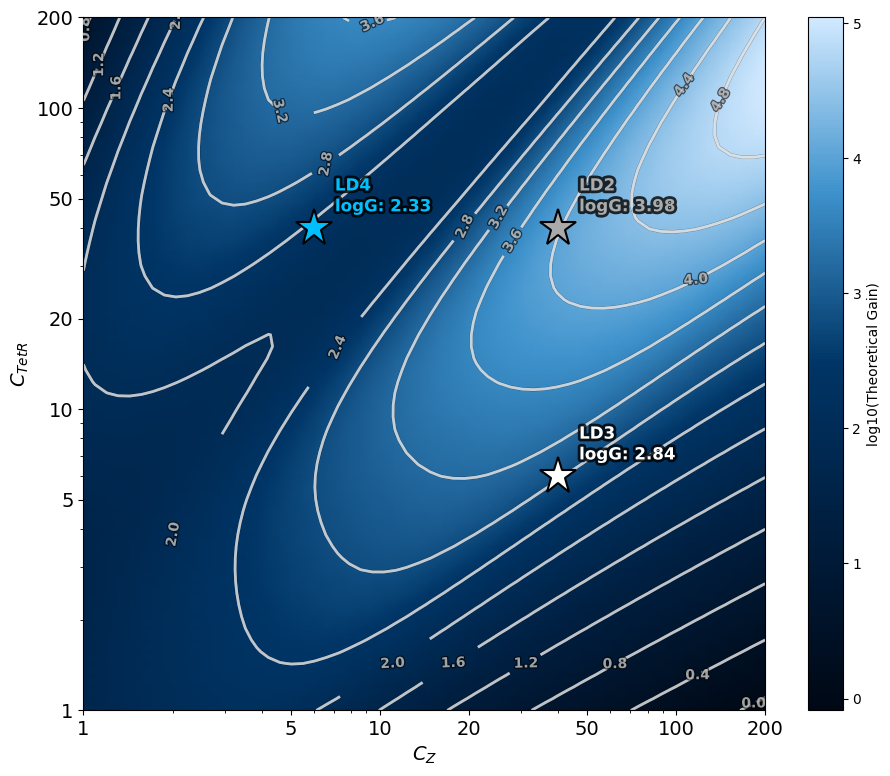

In [10]:
num = 60
C_range = np.logspace(0, 2.3, num)
X_vals = np.logspace(-2, 3, 1000)
CZ_m, CT_m = np.meshgrid(C_range, C_range)
gain_m = np.zeros((num, num))

for i, ct in enumerate(C_range):
    for j, cz in enumerate(C_range):
        gain_m[i, j] = get_gain_penalty(ct, cz, omega_TetR_unit,stability_factor, Kd_Y_SR, n_Y, beta_Y, X_vals)

fig, ax = plt.subplots(figsize=(11, 9))
im = ax.pcolormesh(CZ_m, CT_m, np.log10(gain_m + 1e-5), cmap=create_ice_cmap(), shading='gouraud')

CS = ax.contour(CZ_m, CT_m, np.log10(gain_m + 1e-5), colors='white', linewidths=2.0, alpha=0.5, levels=12)
plt.setp(CS.collections, path_effects=[path_effects.withStroke(linewidth=2.5, foreground='#000000', alpha=0.4), path_effects.Normal()])
clbls = ax.clabel(CS, inline=True, fontsize=10, fmt='%1.1f', colors='white')
plt.setp(clbls, fontweight='bold', path_effects=[path_effects.withStroke(linewidth=1.8, foreground='#000000', alpha=0.6)])

for name, s in designs.items():
    g = get_gain_penalty(s['C_TetR'], s['C_Z'], omega_TetR_unit,stability_factor, Kd_Y_SR, n_Y, beta_Y, X_vals)
    ax.plot(s['C_Z'], s['C_TetR'], marker='*', markersize=28, color=s['color'],
            markeredgecolor='black', markeredgewidth=1.5, zorder=10)
    txt = ax.annotate(f"{name}\nlogG: {np.log10(g + 1e-5):.2f}",
                      xy=(s['C_Z'], s['C_TetR']), xytext=(15, 12), textcoords='offset points',
                      color=s['color'], fontsize=12, fontweight='bold', zorder=11)
    txt.set_path_effects([path_effects.withStroke(linewidth=4, foreground='black', alpha=0.8)])

ax.set_xscale('log'); ax.set_yscale('log')
ticks = [1, 5, 10, 20, 50, 100, 200]
ax.set_xticks(ticks)
ax.set_yticks(ticks)
ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())
ax.get_yaxis().set_major_formatter(plt.ScalarFormatter())
ax.set_xlabel('$C_Z$', fontsize=14)
ax.set_ylabel('$C_{TetR}$', fontsize=14)
plt.tick_params(axis='both', labelsize=14)
plt.colorbar(im, label='log10(Theoretical Gain)')
plt.show()

In [11]:
filename = 'Butyrate_final_stats.csv'
try:
    df = pd.read_csv(filename)
    df['Kd'] = df['Kd'].apply(clean_param)
    df['Beta'] = df['Beta'].apply(clean_param)
    emp = {row['Construct']: row for _, row in df.iterrows()}

    # Simple Regulation  BD1
    Kd_Y_SR = emp['BD1']['Kd']
    n_Y = clean_param(emp['BD1']['Hill (n)'])
    beta_Y = emp['BD1']['Beta']
#anchor bd4
    Kd_eff_BD4 = emp['BD4']['Kd']
    f_req = (Kd_eff_BD4**n_Y) / (Kd_Y_SR**n_Y + Kd_eff_BD4**n_Y)
    S_TetR_BD4 = 40.0 * 2.0
    TetR_tot_target = 1.0 + S_TetR_BD4 * (1.0 / (0.5 + 1.0))
    rho_TetR_BD4 = TetR_tot_target / (beta_Y + (1.0 - beta_Y) * f_req)
    omega_TetR_unit = rho_TetR_BD4 / 40.0

except FileNotFoundError:
    Kd_Y_SR, n_Y, beta_Y = 5.0, 2.0, 0.05
    omega_TetR_unit = 2.0

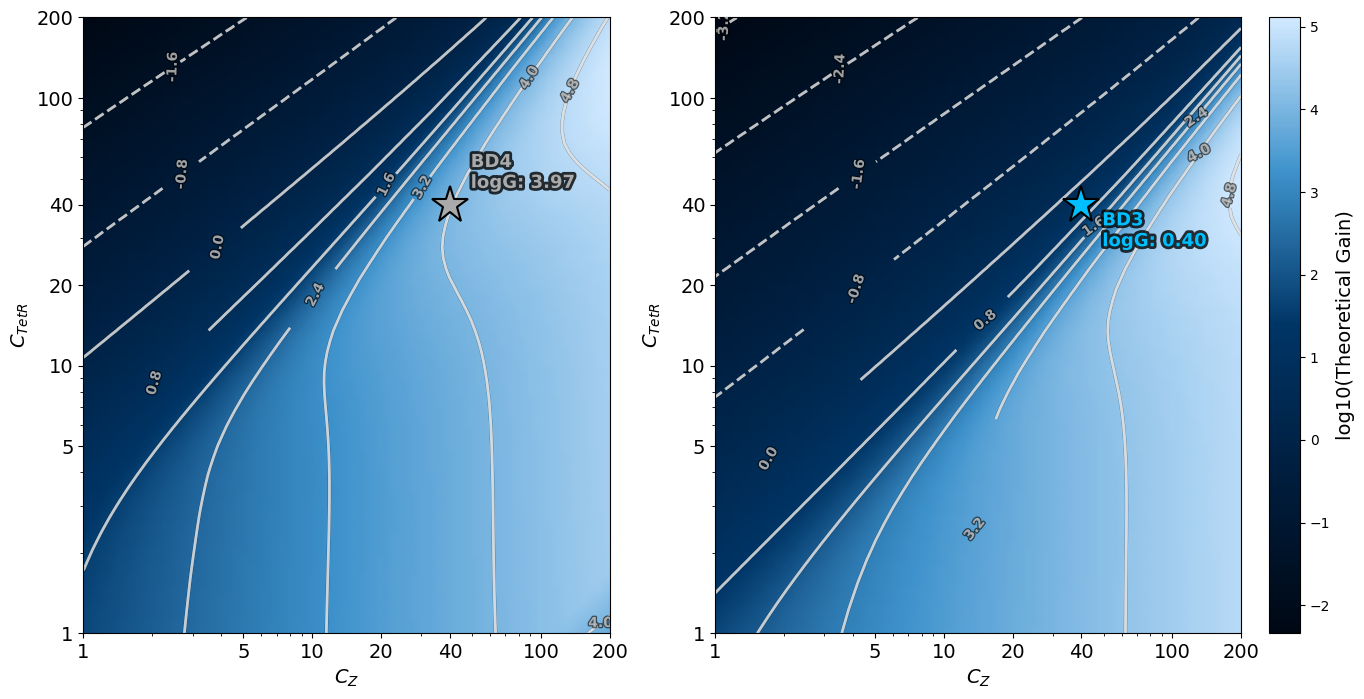

In [12]:
num = 60
C_range = np.logspace(0, 2.3, num)
X_vals = np.logspace(-2, 3, 1000)
CZ_m, CT_m = np.meshgrid(C_range, C_range)

gain_LVA = np.zeros((num, num))
gain_WT = np.zeros((num, num))

for i, ct in enumerate(C_range):
    for j, cz in enumerate(C_range):
        gain_LVA[i, j] = get_gain(ct, cz, omega_TetR_unit,1, Kd_Y_SR, n_Y, beta_Y, X_vals)
        gain_WT[i, j]  = get_gain(ct, cz, omega_TetR_unit,3, Kd_Y_SR, n_Y, beta_Y, X_vals)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
cmap = create_ice_cmap()
contour_args = {'colors': 'white', 'linewidths': 2.0, 'alpha': 0.5, 'levels': 10}
path_eff = [path_effects.withStroke(linewidth=2.5, foreground='#000000', alpha=0.4), path_effects.Normal()]

ax1 = axes[0]
im1 = ax1.pcolormesh(CZ_m, CT_m, np.log10(gain_LVA + 1e-5), cmap=cmap, shading='gouraud')
CS1 = ax1.contour(CZ_m, CT_m, np.log10(gain_LVA + 1e-5), **contour_args)
plt.setp(CS1.collections, path_effects=path_eff)
clbls1 = ax1.clabel(CS1, inline=True, fontsize=10, fmt='%1.1f', colors='white')
plt.setp(clbls1, fontweight='bold', path_effects=[path_effects.withStroke(linewidth=1.8, foreground='#000000', alpha=0.6)])

g_bd4 = get_gain(40, 40, omega_TetR_unit,1, Kd_Y_SR, n_Y, beta_Y, X_vals)
ax1.plot(40, 40, marker='*', markersize=28, color='#AAAAAA', markeredgecolor='black', markeredgewidth=1.5, zorder=10)
txt1 = ax1.annotate(f"BD4\nlogG: {np.log10(g_bd4 + 1e-5):.2f}",
                    xy=(40, 40), xytext=(15, 12), textcoords='offset points',
                    color='#AAAAAA', fontsize=13, fontweight='bold', zorder=11)
txt1.set_path_effects([path_effects.withStroke(linewidth=4, foreground='black', alpha=0.8)])

ax1.set_xscale('log'); ax1.set_yscale('log')
ax1.set_xlabel('$C_Z$', fontsize=14)
ax1.set_ylabel('$C_{TetR}$', fontsize=14)

ax2 = axes[1]
im2 = ax2.pcolormesh(CZ_m, CT_m, np.log10(gain_WT + 1e-5), cmap=cmap, shading='gouraud')
CS2 = ax2.contour(CZ_m, CT_m, np.log10(gain_WT + 1e-5), **contour_args)
plt.setp(CS2.collections, path_effects=path_eff)
clbls2 = ax2.clabel(CS2, inline=True, fontsize=10, fmt='%1.1f', colors='white')
plt.setp(clbls2, fontweight='bold', path_effects=[path_effects.withStroke(linewidth=1.8, foreground='#000000', alpha=0.6)])

g_bd3 = get_gain(40, 40, omega_TetR_unit, 3, Kd_Y_SR, n_Y, beta_Y, X_vals)
ax2.plot(40, 40, marker='*', markersize=28, color='#00BFFF', markeredgecolor='black', markeredgewidth=1.5, zorder=10)
txt2 = ax2.annotate(f"BD3\nlogG: {np.log10(g_bd3 + 1e-5):.2f}",
                    xy=(40, 40), xytext=(15, -30), textcoords='offset points',
                    color='#00BFFF', fontsize=13, fontweight='bold', zorder=11)
txt2.set_path_effects([path_effects.withStroke(linewidth=4, foreground='black', alpha=0.8)])

ax2.set_xscale('log'); ax2.set_yscale('log')
ax2.set_xlabel('$C_Z$', fontsize=14)
ax2.set_ylabel('$C_{TetR}$', fontsize=14)


ticks = [1, 5, 10, 20, 40, 100, 200]
for ax in [ax1, ax2]:
    ax.set_xticks(ticks); ax.set_yticks(ticks)
    ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())
    ax.get_yaxis().set_major_formatter(plt.ScalarFormatter())

cbar = fig.colorbar(im1, ax=axes.ravel().tolist(), pad=0.02)
cbar.set_label('log10(Theoretical Gain)', fontsize=14)
ax1.tick_params(axis='both', labelsize=14)
ax2.tick_params(axis='both', labelsize=14)
plt.show()

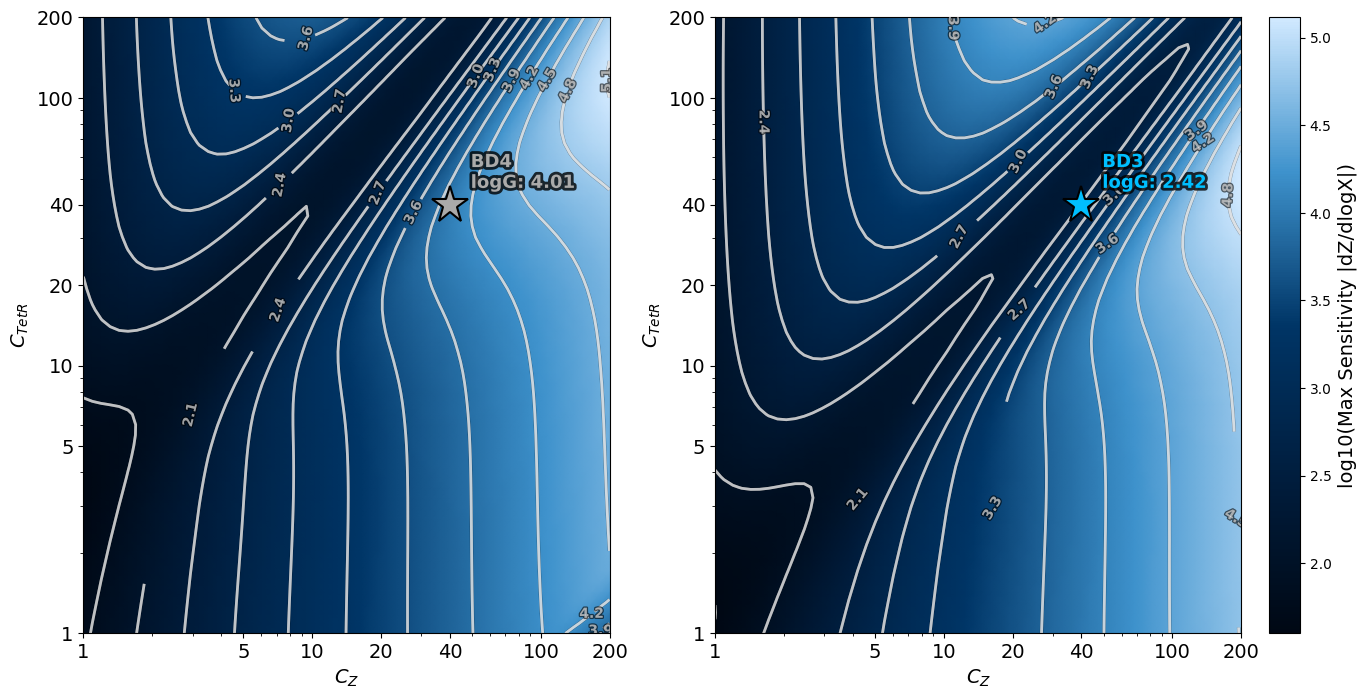

In [13]:

filename = 'Butyrate_final_stats.csv'
try:
    df = pd.read_csv(filename)
    df['Kd'] = df['Kd'].apply(clean_param)
    df['Beta'] = df['Beta'].apply(clean_param)
    emp = {row['Construct']: row for _, row in df.iterrows()}

    Kd_Y_SR = emp['BD1']['Kd']
    n_Y = clean_param(emp['BD1']['Hill (n)'])
    beta_Y = emp['BD1']['Beta']

    Kd_eff_BD4 = emp['BD4']['Kd']
    f_req = (Kd_eff_BD4**n_Y) / (Kd_Y_SR**n_Y + Kd_eff_BD4**n_Y)
    TetR_tot_target = 1.0 + 80.0 * (1.0 / 1.5)
    omega_TetR_unit = (TetR_tot_target / (beta_Y + (1.0 - beta_Y) * f_req)) / 40.0
except:
    Kd_Y_SR, n_Y, beta_Y = 5.0, 2.0, 0.05
    omega_TetR_unit = 2.0

num = 60
C_range = np.logspace(0, 2.3, num)
X_vals = np.logspace(-2, 3, 1000)
CZ_m, CT_m = np.meshgrid(C_range, C_range)

gain_LVA = np.zeros((num, num))
gain_WT = np.zeros((num, num))

for i, ct in enumerate(C_range):
    for j, cz in enumerate(C_range):
        gain_LVA[i, j] = get_gain_penalty(ct, cz, omega_TetR_unit, 1.0, Kd_Y_SR, n_Y, beta_Y, X_vals)
        gain_WT[i, j]  = get_gain_penalty(ct, cz, omega_TetR_unit, 3.0, Kd_Y_SR, n_Y, beta_Y, X_vals)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
cmap = create_ice_cmap()

contour_args = {'colors': 'white', 'linewidths': 2.0, 'alpha': 0.5, 'levels': 12}
path_eff = [path_effects.withStroke(linewidth=2.5, foreground='#000000', alpha=0.4), path_effects.Normal()]
ax1 = axes[0]
im1 = ax1.pcolormesh(CZ_m, CT_m, np.log10(gain_LVA + 1e-5), cmap=cmap, shading='gouraud')
CS1 = ax1.contour(CZ_m, CT_m, np.log10(gain_LVA + 1e-5), **contour_args)
plt.setp(CS1.collections, path_effects=path_eff)
clbls1 = ax1.clabel(CS1, inline=True, fontsize=10, fmt='%1.1f', colors='white')
plt.setp(clbls1, fontweight='bold', path_effects=[path_effects.withStroke(linewidth=1.8, foreground='#000000', alpha=0.6)])

g_bd4 = get_gain_penalty(40, 40, omega_TetR_unit, 1.0, Kd_Y_SR, n_Y, beta_Y, X_vals)
ax1.plot(40, 40, marker='*', markersize=28, color='#AAAAAA', markeredgecolor='black', markeredgewidth=1.5, zorder=10)
txt1 = ax1.annotate(f"BD4\nlogG: {np.log10(g_bd4 + 1e-5):.2f}",
                    xy=(40, 40), xytext=(15, 12), textcoords='offset points',
                    color='#AAAAAA', fontsize=13, fontweight='bold', zorder=11)
txt1.set_path_effects([path_effects.withStroke(linewidth=4, foreground='black', alpha=0.8)])

ax1.set_xscale('log'); ax1.set_yscale('log')
ax1.set_xlabel('$C_Z$', fontsize=14)
ax1.set_ylabel('$C_{TetR}$', fontsize=14)
plt.tick_params(axis='both', labelsize=14)


ax2 = axes[1]
im2 = ax2.pcolormesh(CZ_m, CT_m, np.log10(gain_WT + 1e-5), cmap=cmap, shading='gouraud')
CS2 = ax2.contour(CZ_m, CT_m, np.log10(gain_WT + 1e-5), **contour_args)
plt.setp(CS2.collections, path_effects=path_eff)
clbls2 = ax2.clabel(CS2, inline=True, fontsize=10, fmt='%1.1f', colors='white')
plt.setp(clbls2, fontweight='bold', path_effects=[path_effects.withStroke(linewidth=1.8, foreground='#000000', alpha=0.6)])

g_bd3 = get_gain_penalty(40, 40, omega_TetR_unit, 3.0, Kd_Y_SR, n_Y, beta_Y, X_vals)
ax2.plot(40, 40, marker='*', markersize=28, color='#00BFFF', markeredgecolor='black', markeredgewidth=1.5, zorder=10)
txt2 = ax2.annotate(f"BD3\nlogG: {np.log10(g_bd3 + 1e-5):.2f}",
                    xy=(40, 40), xytext=(15, 12), textcoords='offset points',
                    color='#00BFFF', fontsize=13, fontweight='bold', zorder=11)
txt2.set_path_effects([path_effects.withStroke(linewidth=4, foreground='black', alpha=0.8)])

ax2.set_xscale('log'); ax2.set_yscale('log')
ax2.set_xlabel('$C_Z$', fontsize=14)
ax2.set_ylabel('$C_{TetR}$', fontsize=14)


ticks = [1, 5, 10, 20, 40, 100, 200]
for ax in [ax1, ax2]:
    ax.set_xticks(ticks); ax.set_yticks(ticks)
    ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())
    ax.get_yaxis().set_major_formatter(plt.ScalarFormatter())


cbar = fig.colorbar(im1, ax=axes.ravel().tolist(), pad=0.02)
cbar.set_label('log10(Max Sensitivity |dZ/dlogX|)', fontsize=14)
ax1.tick_params(axis='both', labelsize=14)
ax2.tick_params(axis='both', labelsize=14)
plt.show()